### Read in dataset

In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split

df = pd.read_csv('../DATA/WELFake_Dataset.csv')
print(df.head())

   Unnamed: 0                                              title  \
0           0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1           1                                                NaN   
2           2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
3           3  Bobby Jindal, raised Hindu, uses story of Chri...   
4           4  SATAN 2: Russia unvelis an image of its terrif...   

                                                text  label  
0  No comment is expected from Barack Obama Membe...      1  
1     Did they post their votes for Hillary already?      1  
2   Now, most of the demonstrators gathered last ...      1  
3  A dozen politically active pastors came here f...      0  
4  The RS-28 Sarmat missile, dubbed Satan 2, will...      1  


## Step 1: Sample & Vectorize
We sample 20,000 articles and convert text to TF-IDF features.### Clean and Vectorize text data

In [16]:
sample = df.sample(n=20000,random_state=1).reset_index(drop=True)
sample = sample.drop(columns=['Unnamed: 0'])
sample = sample.dropna()

# Inspect sampled data
print(sample[sample['label'] == 0].size / sample.size)
print(sample[sample['label'] == 1].size / sample.size)

vectorizer = TfidfVectorizer(
    max_features=2000,
    stop_words='english',
    max_df=0.85,
    min_df=2,
    ngram_range=(1, 2),
    strip_accents='unicode',
    lowercase=True
)

tfidf_matrix = vectorizer.fit_transform(sample['text'])
feature_names = vectorizer.get_feature_names_out()

0.4835508086049675
0.5164491913950325


## Step 2: Inspect TF-IDF Features
A random sample of the features the vectorizer learned.

In [17]:
# Inspect some features
np.random.choice(feature_names, size=50, replace=False)

array(['ahead', 'date', 'construction', 'biden', 'direct', 'provided',
       'threat', 'guy', 'send', 'ready', 'especially', 'что',
       'involvement', 'nomination', 'liberals', 'told reporters',
       'officials said', 'coal', 'discovered', 'terror', 'beat', 'highly',
       'black lives', 'thomas', '100', 'finance', 'simply', 'list',
       'internal', 'open', 'drug', 'include', 'mainstream media',
       'global', 'americans', 'small', 'asked', 'entering', 'tensions',
       'designed', 'jim', 'ruling', 'previously', 'original', 'trip',
       'israel', 'team', 'proposed', 'die', 'corruption'], dtype=object)

## Step 3: Find Optimal Clusters
We use silhouette scores to find the best number of clusters. This is commented out after being run once — we found k=15 works well.### Cluster

In [18]:
# Algorithm for finding optimal cluster number
def find_optimal_clusters(tfidf_matrix, max_clusters=20):
    """
    Standard implementation of elbow method and silhouette score to find optimal number of clusters.
    """
    inertias = []
    silhouette_scores = []
    K_range = range(2, min(max_clusters + 1, (tfidf_matrix.shape)[0]))
    
    print("\nEvaluating optimal number of clusters...")
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(tfidf_matrix)
        inertias.append(kmeans.inertia_)
        
        # Calculate silhouette score
        score = silhouette_score(tfidf_matrix, kmeans.labels_, sample_size=min(1000, (tfidf_matrix.shape)[0]))
        silhouette_scores.append(score)
        print(f"  k={k}: silhouette={score:.3f}")
    
    # Suggest k with highest silhouette score
    best_k = K_range[np.argmax(silhouette_scores)]
    print(f"\nSuggested number of clusters: {best_k}")
    
    return best_k

# Commented out after being used once to save time
# n_clusters = find_optimal_clusters(tfidf_matrix, max_clusters=30)

## Step 4: Fit KMeans Clustering

In [19]:
# Set n_clusters to 15
n_clusters = 15

# Fit clustering algorithm and assign cluster labels to sample
kmeans = KMeans(n_clusters=n_clusters, random_state=1, n_init=10)
cluster_labels = kmeans.fit_predict(tfidf_matrix)
sample['cluster'] = cluster_labels

## Step 5: Inspect Cluster Composition
How much fake news is in each cluster?

In [20]:
for cluster in range(n_clusters):
    cluster_mask = sample['cluster'] == cluster
    cluster_data = sample[cluster_mask]
    size = len(cluster_data)
    fake_fraction = (cluster_data['label']==1).sum() / size

    print(f'Cluster {cluster+1}: Size={size}, Fake Fraction={fake_fraction:.2f}')

Cluster 1: Size=953, Fake Fraction=0.09
Cluster 2: Size=714, Fake Fraction=0.04
Cluster 3: Size=6656, Fake Fraction=0.67
Cluster 4: Size=1977, Fake Fraction=0.16
Cluster 5: Size=1084, Fake Fraction=0.35
Cluster 6: Size=576, Fake Fraction=0.26
Cluster 7: Size=392, Fake Fraction=0.73
Cluster 8: Size=329, Fake Fraction=0.09
Cluster 9: Size=890, Fake Fraction=0.46
Cluster 10: Size=575, Fake Fraction=0.93
Cluster 11: Size=606, Fake Fraction=0.27
Cluster 12: Size=2760, Fake Fraction=0.72
Cluster 13: Size=292, Fake Fraction=0.15
Cluster 14: Size=822, Fake Fraction=0.50
Cluster 15: Size=1223, Fake Fraction=0.79


## Step 6: Top Terms per Cluster
What topics define each cluster?

In [21]:
# Get top terms per cluster
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()
for cluster in range(n_clusters):
    top_terms = [terms[ind] for ind in order_centroids[cluster, :5]]
    cluster_mask = sample['cluster'] == cluster
    cluster_data = sample[cluster_mask]
    size = len(cluster_data)
    fake_fraction = (cluster_data['label']==1).sum() / size
    print(f"Cluster {cluster+1} top terms: {', '.join(top_terms)} ---- Fake Fraction: {fake_fraction:.2f}")

Cluster 1 top terms: eu, said, minister, party, european ---- Fake Fraction: 0.09
Cluster 2 top terms: mr, mr trump, said, trump, ms ---- Fake Fraction: 0.04
Cluster 3 top terms: said, people, like, new, just ---- Fake Fraction: 0.67
Cluster 4 top terms: said, house, trump, tax, senate ---- Fake Fraction: 0.16
Cluster 5 top terms: russia, syria, russian, said, syrian ---- Fake Fraction: 0.35
Cluster 6 top terms: court, supreme court, supreme, judge, said ---- Fake Fraction: 0.26
Cluster 7 top terms: comey, fbi, clinton, investigation, fbi director ---- Fake Fraction: 0.73
Cluster 8 top terms: korea, north korea, north, korean, nuclear ---- Fake Fraction: 0.09
Cluster 9 top terms: police, said, officers, officer, people ---- Fake Fraction: 0.46
Cluster 10 top terms: twitter com, com, twitter, pic, pic twitter ---- Fake Fraction: 0.93
Cluster 11 top terms: iran, saudi, israel, arabia, saudi arabia ---- Fake Fraction: 0.27
Cluster 12 top terms: trump, donald, donald trump, president, said

## Step 7: Logistic Regression per Cluster
We train a classifier on each cluster individually and compare accuracy to the full-dataset model.

cluster 0
cluster 1
cluster 2
cluster 3
cluster 4
cluster 5
cluster 6
cluster 7
cluster 8
cluster 9
cluster 10
cluster 11
cluster 12
cluster 13
cluster 14
0.9188916876574307
[0.86910995 1.         0.88363363 0.9040404  0.9078341  0.75
 0.89873418 0.84848485 0.84269663 0.94782609 0.83606557 0.89673913
 0.88135593 0.87878788 0.91836735]


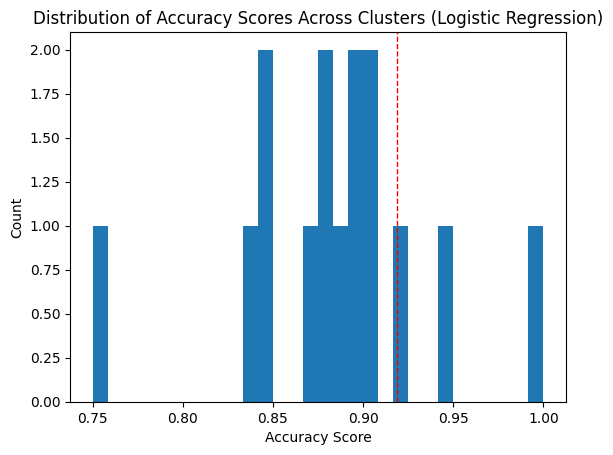

In [22]:
# Logistic Regression per cluster
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Split in to train/test
def cluster_logistic_regression(sample_1, tfidf_matrix, c):
    X, y = ((tfidf_matrix.toarray())[sample_1['cluster'] == c]), sample_1[sample_1['cluster'] == c]['label']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    return X_train, X_test, y_train, y_test

cluster_scores = np.zeros(n_clusters)
for c in range(n_clusters):
    print(f'cluster {c}')
    # print(f"\nCluster {c} Logistic Regression:")
    X_train, X_test, y_train, y_test = cluster_logistic_regression(sample, tfidf_matrix, c)
    model = LogisticRegression(max_iter=1000)
    try:
        model.fit(X_train, y_train)
        scor = model.score(X_test, y_test)
        cluster_scores[c] = scor
    except Exception as e:
        print('')
        # print(f"  Error training cluster {c}: {e}")

# Train on full dataset
X_train, X_test, y_train, y_test = train_test_split(tfidf_matrix.toarray(), sample['label'], test_size=0.2, random_state=42)
full_model = LogisticRegression(max_iter=1000)
full_model.fit(X_train, y_train)
full_score = full_model.score(X_test, y_test)
print(full_score)

print(cluster_scores)

plt.hist(cluster_scores,bins=30)
plt.axvline(full_score, color='red', linestyle='dashed', linewidth=1, label='Full Model Score')
plt.title('Distribution of Accuracy Scores Across Clusters (Logistic Regression)')
plt.xlabel('Accuracy Score')
plt.ylabel('Count')
plt.savefig("../OUTPUT/accuracy_score_dist_across_clusters_LR.png", dpi=300, bbox_inches="tight")

In [23]:
mu, sigma = np.mean(cluster_scores), np.std(cluster_scores)
print(f"Cluster Scores: mean={mu:.3f}, std={sigma:.3f}")

# Calculate if variance of cluster scores is significantly different from full model score using a t-test
from scipy import stats
t_stat, p_value = stats.ttest_1samp(cluster_scores, full_score)
print(f"T-statistic: {t_stat:.3f}, P-value: {p_value:.3f}")

Cluster Scores: mean=0.884, std=0.054
T-statistic: -2.406, P-value: 0.030


## Step 8: LinearSVC per Cluster
We repeat the same analysis using a Support Vector Classifier and compare results.

Accuracy: 0.9231738035264484
              precision    recall  f1-score   support

           0       0.93      0.91      0.92      1919
           1       0.92      0.93      0.93      2051

    accuracy                           0.92      3970
   macro avg       0.92      0.92      0.92      3970
weighted avg       0.92      0.92      0.92      3970

cluster 0
cluster 1
cluster 2
cluster 3
cluster 4
cluster 5
cluster 6
cluster 7
cluster 8
cluster 9
cluster 10
cluster 11
cluster 12
cluster 13
cluster 14
[0.93717277 1.         0.89864865 0.93434343 0.93087558 0.87931034
 0.92405063 0.86363636 0.87640449 0.97391304 0.89344262 0.93115942
 0.93220339 0.87878788 0.93877551]


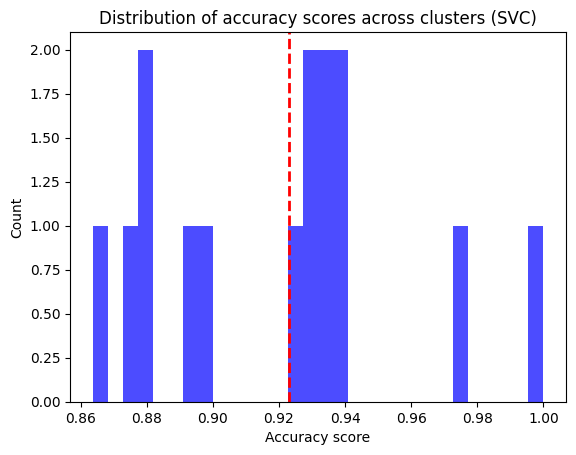

In [24]:
# Do the same with SVC and compare results.
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(tfidf_matrix.toarray(), sample['label'], test_size=0.2, random_state=42)
svm = LinearSVC(C=1.0)
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

full_score = accuracy_score(y_test, y_pred)

# By cluster
def cluster_SVC(sample_1, tfidf_matrix, c):
    X, y = ((tfidf_matrix.toarray())[sample_1['cluster'] == c]), sample_1[sample_1['cluster'] == c]['label']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    return X_train, X_test, y_train, y_test

cluster_scores = np.zeros(n_clusters)
for c in range(n_clusters):
    print(f'cluster {c}')
    # print(f"\nCluster {c} Logistic Regression:")
    X_train, X_test, y_train, y_test = cluster_SVC(sample, tfidf_matrix, c)
    model = LinearSVC(C=1.0)
    try:
        model.fit(X_train, y_train)
        scor = model.score(X_test, y_test)
        cluster_scores[c] = scor
    except Exception as e:
        print('')

print(cluster_scores)

plt.hist(cluster_scores,bins=30,color='blue',alpha=0.7)
plt.axvline(full_score, color='red', linestyle='dashed', linewidth=2, label='Full Model Score')
plt.title('Distribution of accuracy scores across clusters (SVC)')
plt.xlabel('Accuracy score')
plt.ylabel('Count')
plt.savefig("../OUTPUT/accuracy_score_dist_across_clusters_SVC.png", dpi=300, bbox_inches="tight")

In [25]:
mu, sigma = np.mean(cluster_scores), np.std(cluster_scores)
print(f"Cluster Scores: mean={mu:.3f}, std={sigma:.3f}")

# Calculate if variance of cluster scores is significantly different from full model score using a t-test
from scipy import stats
t_stat, p_value = stats.ttest_1samp(cluster_scores, full_score)
print(f"T-statistic: {t_stat:.3f}, P-value: {p_value:.3f}")

Cluster Scores: mean=0.920, std=0.037
T-statistic: -0.373, P-value: 0.714


## Summary
- Clusters reveal thematic groupings in the news articles
- Both Logistic Regression and LinearSVC achieve high accuracy on the full dataset
- Accuracy varies across clusters, some topics are harder to classify than others
- The t-test tells us whether cluster-level performance differs significantly from the global model